In [7]:
# ── Cell 1: Setup ──────────────────────────────────────────────────────────
import os, sys, random
import numpy as np
from dotenv import load_dotenv
load_dotenv()

# Ensure project root is importable when running from notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Determinism
random.seed(42)
np.random.seed(42)
os.environ["MLX_SEED"] = "42"  # mlx_lm RNG

# Results directory
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'benchmarks', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
CACHE_DIR = os.path.join(PROJECT_ROOT, '.cache')
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Plug in your LLM here ──────────────────────────────────────────────────
# llm_fn must be Callable[[str], str]  (prompt in, completion out).
#
# Example 1 — OpenAI
# import openai
# client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])
# def llm_fn(prompt: str) -> str:
#     r = client.chat.completions.create(
#         model='gpt-4o-mini',
#         messages=[{'role': 'user', 'content': prompt}],
#         max_tokens=256,
#     )
#     return r.choices[0].message.content
#
# Ollama local — zero API cost, good for iteration
from vague.adapters.anthropic import anthropic_fn
llm_fn = anthropic_fn(model="claude-haiku-4-5-20251001", max_tokens=256)

# For publication-quality results switch to:
# from vague.adapters.anthropic import anthropic_fn
# llm_fn = anthropic_fn(model="claude-haiku-4-5-20251001", max_tokens=256)
#
# Example 3 — local Ollama
# import requests
# def llm_fn(prompt: str) -> str:
#     r = requests.post('http://localhost:11434/api/generate',
#                       json={'model': 'llama3', 'prompt': prompt, 'stream': False})
#     return r.json()['response']
N_SAMPLES = 200
evaluator = LongBenchEval(llm_fn=llm_fn, cache_dir=CACHE_DIR)
results: list[EvalResult] = evaluator.compare_all(task='qasper', n_samples=N_SAMPLES)

print('Setup complete.')
print('RESULTS_DIR:', RESULTS_DIR)

qasper/vague: 100%|███████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.09sample/s]
./benchmarks/longbench.py:400: RuntimeWarning: Mean of empty slice
  latency_ms=float(np.nanmean(latencies)) if latencies else 0.0,
qasper/full_context: 100%|███████████████████████████████████████████| 200/200 [00:00<00:00, 457.50sample/s]

Setup complete.
RESULTS_DIR: ./benchmarks/results


qasper/full_context: 100%|████████████████████████████████████████████| 200/200 [10:57<00:00,  3.29s/sample]

vague            F1=0.110  tokens=1722  cr=2.87  latency=3284.7ms
naive_rag        F1=0.122  tokens=1691  cr=2.91  latency=3116.5ms
full_context     F1=0.122  tokens=3686  cr=1.30  latency=3288.4ms


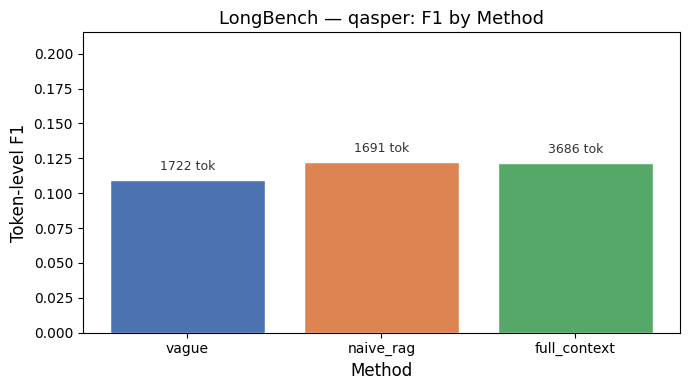

Saved: ./benchmarks/results/longbench_qasper_f1.png


In [2]:
# ── Cell 2: LongBench — compare_all on qasper ──────────────────────────────
from benchmarks.longbench import LongBenchEval, EvalResult

N_SAMPLES = 200   # increase to 200 for publication-quality results

evaluator = LongBenchEval(llm_fn=llm_fn, cache_dir=CACHE_DIR)
results: list[EvalResult] = evaluator.compare_all(task='qasper', n_samples=N_SAMPLES)

for r in results:
    print(f'{r.method:15s}  F1={r.f1_score:.3f}  '
          f'tokens={r.avg_input_tokens}  '
          f'cr={r.compression_ratio:.2f}  '
          f'latency={r.latency_ms:.1f}ms')

# Bar chart: F1 vs method, annotated with avg token counts
methods      = [r.method for r in results]
f1_scores    = [r.f1_score for r in results]
token_counts = [r.avg_input_tokens for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    methods, f1_scores,
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='white',
)
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Token-level F1', fontsize=12)
ax.set_title('LongBench — qasper: F1 by Method', fontsize=13)
top = max(f1_scores) if f1_scores else 1.0
ax.set_ylim(0, min(1.05, top * 1.35 + 0.05))

for bar, tok in zip(bars, token_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{tok} tok',
        ha='center', va='bottom', fontsize=9, color='#333333',
    )

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, 'longbench_qasper_f1.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('Saved:', out_path)

needle sweep: 100%|███████████████████████████████████████████████████████| 35/35 [08:18<00:00, 14.24s/cell]

Saved: ./benchmarks/results/needle_sweep.csv
 context_length  position  found_rate  tokens_used
            512      0.00         0.0          526
            512      0.10         0.4          527
            512      0.25         1.0          527
            512      0.50         0.8          527
            512      0.75         1.0          526
            512      0.90         1.0          526
            512      1.00         1.0          526
           1024      0.00         0.0         1041
           1024      0.10         0.8         1041
           1024      0.25         0.8         1041
           1024      0.50         1.0         1041
           1024      0.75         1.0         1041
           1024      0.90         1.0         1041
           1024      1.00         1.0         1040
           2048      0.00         0.2         1650
           2048      0.10         1.0         1650
           2048      0.25         1.0         1650
           2048      0.50         1.0

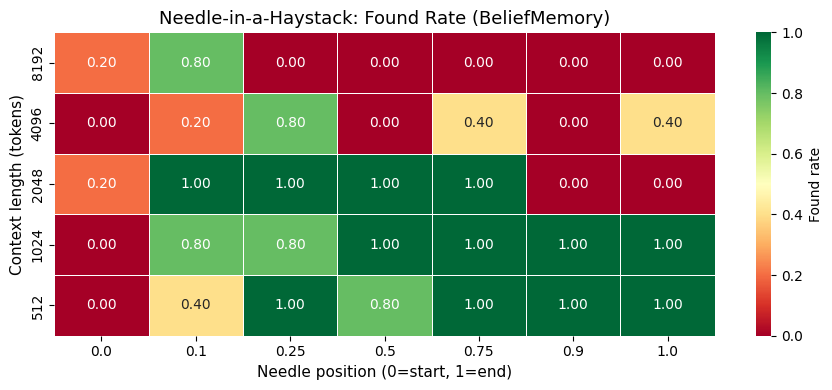

Saved: ./benchmarks/results/needle_heatmap.png


In [4]:
# ── Cell 3: Needle heatmap ─────────────────────────────────────────────────
_needle_csv = os.path.join(RESULTS_DIR, 'needle_sweep.csv')
_needle_out = os.path.join(RESULTS_DIR, 'needle_heatmap.png')

if os.path.exists(_needle_csv):
    print('Needle results cached — loading from disk')
    sweep_df = pd.read_csv(_needle_csv)
else:
    from benchmarks.needle import run_needle_sweep
    CONTEXT_LENGTHS = [512, 1024, 2048, 4096, 8192]
    POSITIONS       = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    sweep_df = run_needle_sweep(
        context_lengths=CONTEXT_LENGTHS,
        positions=POSITIONS,
        llm_fn=llm_fn,
    )
    sweep_df.to_csv(_needle_csv, index=False)
    print('Saved:', _needle_csv)

print(sweep_df.to_string(index=False))

pivot = sweep_df.pivot(index='context_length', columns='position', values='found_rate')
pivot = pivot.sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, linewidths=0.5, cbar_kws={'label': 'Found rate'})
ax.set_title('Needle-in-a-Haystack: Found Rate (BeliefMemory)', fontsize=13)
ax.set_xlabel('Needle position (0=start, 1=end)', fontsize=11)
ax.set_ylabel('Context length (tokens)', fontsize=11)
plt.tight_layout()
plt.savefig(_needle_out, dpi=150)
plt.show()
print('Saved:', _needle_out)


=== hotpotqa ===


hotpotqa/vague: 100%|█████████████████████████████████████████████████| 200/200 [01:30<00:00,  2.21sample/s]
./benchmarks/longbench.py:400: RuntimeWarning: Mean of empty slice
  latency_ms=float(np.nanmean(latencies)) if latencies else 0.0,
hotpotqa/full_context: 100%|█████████████████████████████████████████| 200/200 [00:00<00:00, 205.26sample/s]


  vague            F1=0.042  tokens=1758  cr=7.39x
  naive_rag        F1=0.048  tokens=1796  cr=7.20x
  full_context     F1=0.043  tokens=4087  cr=3.11x
=== multifieldqa_en ===


multifieldqa_en/vague: 100%|██████████████████████████████████████████| 150/150 [00:33<00:00,  4.46sample/s]
./benchmarks/longbench.py:400: RuntimeWarning: Mean of empty slice
  latency_ms=float(np.nanmean(latencies)) if latencies else 0.0,
multifieldqa_en/full_context: 100%|███████████████████████████████████| 150/150 [04:14<00:00,  1.70s/sample]

  vague            F1=0.173  tokens=2022  cr=3.71x
  naive_rag        F1=0.182  tokens=1962  cr=3.72x
  full_context     F1=0.187  tokens=3737  cr=1.78x


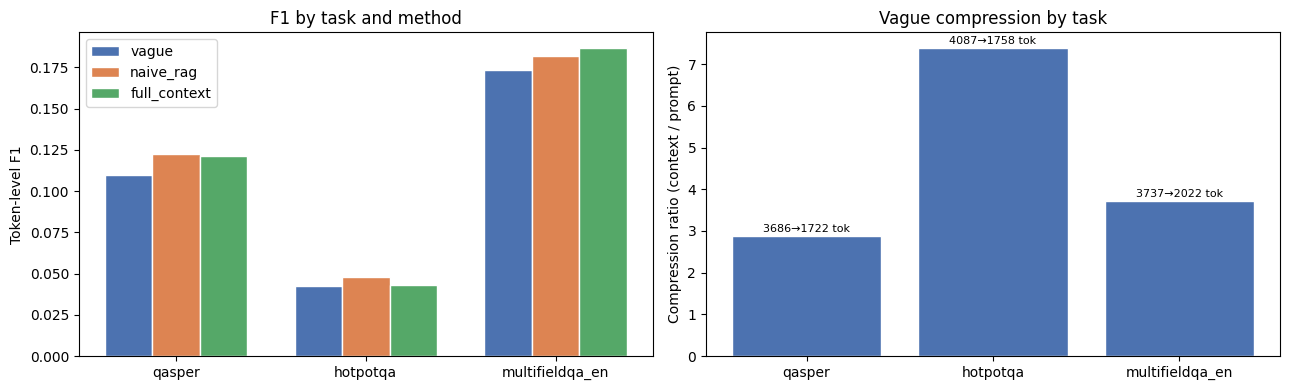

Saved: ./benchmarks/results/multitask_benchmark.png


In [8]:
# ── Cell 6: Multi-task benchmark — hotpotqa + multifieldqa_en ──────────────
from benchmarks.longbench import LongBenchEval, EvalResult
import matplotlib.pyplot as plt
import numpy as np

TASKS = ["qasper", "hotpotqa", "multifieldqa_en"]
N = N_SAMPLES  # consistent with Cell 2

# Reuse qasper results from Cell 2 — avoid redundant re-run
all_task_results: dict[str, list[EvalResult]] = {"qasper": results}  # qasper from Cell 2

for task in ["hotpotqa", "multifieldqa_en"]:
    print(f"=== {task} ===")
    ev = LongBenchEval(llm_fn=llm_fn, cache_dir=CACHE_DIR)
    task_results = ev.compare_all(task=task, n_samples=N)
    all_task_results[task] = task_results
    for r in task_results:
        print(f"  {r.method:15s}  F1={r.f1_score:.3f}  tokens={r.avg_input_tokens}  cr={r.compression_ratio:.2f}x")

# Grouped bar chart: F1 by method, grouped by task
methods = ["vague", "naive_rag", "full_context"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x = np.arange(len(TASKS))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F1
ax = axes[0]
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [next(r.f1_score for r in all_task_results[t] if r.method == method) for t in TASKS]
    ax.bar(x + i * width, vals, width, label=method, color=color, edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(TASKS)
ax.set_ylabel("Token-level F1")
ax.set_title("F1 by task and method")
ax.legend()

# Compression ratio (vague only)
ax = axes[1]
cr_vals = [next(r.compression_ratio for r in all_task_results[t] if r.method == "vague") for t in TASKS]
tok_full = [next(r.avg_input_tokens for r in all_task_results[t] if r.method == "full_context") for t in TASKS]
tok_vague = [next(r.avg_input_tokens for r in all_task_results[t] if r.method == "vague") for t in TASKS]
bars = ax.bar(TASKS, cr_vals, color="#4C72B0", edgecolor="white")
for bar, tf, tv in zip(bars, tok_full, tok_vague):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{tf}→{tv} tok", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Compression ratio (context / prompt)")
ax.set_title("Vague compression by task")

plt.tight_layout()
out_path = os.path.join(RESULTS_DIR, "multitask_benchmark.png")
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)


## Summary Table — All Tasks & Methods

Run after Cell 6 to get the full cross-task comparison.

In [9]:
# ── Cell 7: Summary table (all tasks) ──────────────────────────────────────
from IPython.display import Markdown, display

# Flatten all_task_results → list[EvalResult]
all_results: list = [r for task_rs in all_task_results.values() for r in task_rs]

header = '| task | method | f1_score | f1_std | ci_95 | avg_input_tokens | compression_ratio | latency_ms | n_samples |'
sep    = '|------|--------|----------|--------|-------|-----------------|-------------------|------------|-----------|'
rows   = []
for r in all_results:
    rows.append(
        f'| {r.task} | {r.method} | {r.f1_score:.3f} '
        f'| {r.f1_std:.3f} '
        f'| [{r.f1_ci_low:.3f}, {r.f1_ci_high:.3f}] '
        f'| {r.avg_input_tokens} '
        f'| {r.compression_ratio:.3f} '
        f'| {r.latency_ms:.1f} '
        f'| {r.n_samples} |'
    )

table = '\n'.join([header, sep] + rows)
display(Markdown(table))
print(table)


| task | method | f1_score | f1_std | ci_95 | avg_input_tokens | compression_ratio | latency_ms | n_samples |
|------|--------|----------|--------|-------|-----------------|-------------------|------------|-----------|
| qasper | vague | 0.110 | 0.108 | [0.095, 0.125] | 1722 | 2.874 | nan | 200 |
| qasper | naive_rag | 0.122 | 0.120 | [0.106, 0.140] | 1691 | 2.910 | nan | 200 |
| qasper | full_context | 0.122 | 0.116 | [0.105, 0.139] | 3686 | 1.300 | nan | 200 |
| hotpotqa | vague | 0.042 | 0.055 | [0.035, 0.050] | 1758 | 7.392 | nan | 200 |
| hotpotqa | naive_rag | 0.048 | 0.053 | [0.041, 0.056] | 1796 | 7.199 | nan | 200 |
| hotpotqa | full_context | 0.043 | 0.057 | [0.036, 0.052] | 4087 | 3.113 | nan | 200 |
| multifieldqa_en | vague | 0.173 | 0.163 | [0.147, 0.199] | 2022 | 3.712 | nan | 150 |
| multifieldqa_en | naive_rag | 0.182 | 0.167 | [0.157, 0.212] | 1962 | 3.725 | nan | 150 |
| multifieldqa_en | full_context | 0.187 | 0.182 | [0.159, 0.217] | 3737 | 1.777 | 2793.6 | 150 |

| task | method | f1_score | f1_std | ci_95 | avg_input_tokens | compression_ratio | latency_ms | n_samples |
|------|--------|----------|--------|-------|-----------------|-------------------|------------|-----------|
| qasper | vague | 0.110 | 0.108 | [0.095, 0.125] | 1722 | 2.874 | nan | 200 |
| qasper | naive_rag | 0.122 | 0.120 | [0.106, 0.140] | 1691 | 2.910 | nan | 200 |
| qasper | full_context | 0.122 | 0.116 | [0.105, 0.139] | 3686 | 1.300 | nan | 200 |
| hotpotqa | vague | 0.042 | 0.055 | [0.035, 0.050] | 1758 | 7.392 | nan | 200 |
| hotpotqa | naive_rag | 0.048 | 0.053 | [0.041, 0.056] | 1796 | 7.199 | nan | 200 |
| hotpotqa | full_context | 0.043 | 0.057 | [0.036, 0.052] | 4087 | 3.113 | nan | 200 |
| multifieldqa_en | vague | 0.173 | 0.163 | [0.147, 0.199] | 2022 | 3.712 | nan | 150 |
| multifieldqa_en | naive_rag | 0.182 | 0.167 | [0.157, 0.212] | 1962 | 3.725 | nan | 150 |
| multifieldqa_en | full_context | 0.187 | 0.182 | [0.159, 0.217] | 3737 | 1.777 | 2793.6 | 150 |
